# Position Matters: Statistical Profiles Across the PLL - Player Analysis: Positional

Our first analytical goal focuses on individual players. We will do a positional analysis to determine which players excel at playing in their position. 


## Background
In the PLL, there are nine players plus a goalie per team on the field at a time. There are three attackmen, three midfielders, three defensemen, and a goalie on the field simultaneously. The positions are broken down into their role and key statistics used for evaluation below.

##### Attack (A) - Offense
They are the primary offensive players who focus on scoring goals and setting up plays with their teammates. Their success can be determined by their shooting accuracy, goals scored, and assists. We use the following statistics to do our primary analysis.

*Key Statistics*: Shooting percentage, Average goals per game, Average assists per game
<br>
<br>

##### Midfield (M) - Mostly Offense
Midfielders play both sides of the field and serve as the transition between defense and offense. In the database from the PLL, the label of `M` refers to midfielders who also contribute to scoring when they can. These players cover the most ground of any position, so more general statistics are used.

*Key Statistics*: Shooting percentage, Average points per game, Average assists per game
<br>
<br>

##### Long Stick Midfielder (LSM) - Mostly Defense 
Long Stick Midfielders are defensive specialists who use a long stick (like defensemen) and play midfielder positions. They are typically one of the best defensive playmakers during transitions.

*Key Statistics*: Average groundballs per game, Average caused turnovers per game, Average points per game
<br>
<br>

##### Short Stick Defensive Midfielder (SSDM) - Mostly Defense
Short Stick Defensive Midfielders are also defensive specialists, like LSMs, but they use a short stick to enhance their mobility and speed. They tend to protect against the opposing team's offensive midfielders.

*Key Statistics*: Average groundballs per game, Average caused turnovers per game, Average points per game
<br>
<br>

##### Defense (D) - Defense
Defensemen are the main defensive players on the team who prevent goals and guard the opposing attackmen. Their key statistics are more related to the disruption of the game.

*Key Statistics*: Average groundballs per game, Average caused turnovers per game, Lockdown rating (excluded from this analysis*)
<br>
<br>

##### Faceoff (FO) - Offense
Faceoff players begin each possession by fighting for the ball at the beginning of each period or after every goal. They are highly specialized, so it is very easy to statistically compare them.

*Key Statistics*: Faceoff percentage, Average groundballs per game, Average points per game
<br>
<br>

##### Goalie (G) - Defense
Goalies are the last line of defense and protect the goal from opposing attackmen's shots. They also play a major role in organizing the defensemen.

*Key Statistics*: Save percentage, Average saves per game,
<br>
<br>

*Excluded due to calculation complexity and lack of available statistics. See Defense section below.

## Approach to Analysis
*Step 0* - Establish basic restrictions to ensure bias is limited. Create relevant features for analysis.

*Step 1* - Determine which statistics are position-specific according to the background.

*Step 2* - Investigate overall distributions of data by position.

*Step 3* - Identify stand-out and top-performing players within each position.

*Step 4* - Investigate the top players by investigating a further statistic regarding their position.

## Preparation

In [22]:
#import relevant packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install scipy
import scipy
import scipy.stats as stats
import matplotlib.ticker as mtick

In [6]:
#Import the new cleaned dataset
player_stats_data = pd.read_csv("pll-player-stats-cleaned.csv")
player_stats_data

,First Name,Last Name,Position,Jersey,Team,Games Played,Points,Scoring Points,Total Goals,1Pt Goals,...,2Pt Goals Against,Penalties,Penalties (in minutes),Power Play Goals,Power Play Shots,Power Play Goals Against,Short Handed Goals,Short Handed Shots,Unassisted Goals,Assisted Goals
0,Connor,Shellenberger,A,1.0,Atlas,10,46,23,23,23,...,0,2,2.0,1,1,0,0,0,12,11
1,Michael,Sowers,A,22.0,Waterdogs,10,41,18,18,18,...,0,0,0.0,1,1,0,0,0,14,4
2,Jeff,Teat,A,7.0,Atlas,10,40,17,17,17,...,0,0,0.0,1,4,0,0,0,9,8
3,Pat,Kavanagh,A,51.0,Outlaws,10,37,21,21,21,...,0,7,5.0,0,5,0,0,0,9,12
4,Chris,Kavanagh,A,96.0,Redwoods,10,37,25,23,21,...,0,1,2.0,0,1,0,0,0,11,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Nick,Rowlett,FO,73.0,Chaos,3,0,0,0,0,...,0,0,0.0,0,0,0,0,0,0,0
191,Eric,Dobson,M,66.0,Chaos,3,0,0,0,0,...,0,0,0.0,0,0,0,0,0,0,0
192,Jon,Robbins,LSM,41.0,Archers,1,0,0,0,0,...,0,0,0.0,0,0,0,0,0,0,0
193,Chet,Comizio,SSDM,57.0,Atlas,9,0,0,0,0,...,0,5,3.0,0,0,0,0,0,0,0


#### Preparation - Sample Size
Limit the player sample size to those who have played at least 3 games in the dataset. 

In [7]:
#setting the games played minimum (must have played at least 3 games for data)
positional_analysis = player_stats_data[player_stats_data["Games Played"]>=3].copy()

#check shape of new datasets
print(positional_analysis.shape)

(174, 45)


There are still 174 rows of data, which is enough to continue doing an analysis on with minimal bias.

### Feature Engineering

Create the following features to ensure fair comparison of players regardless of the number of games they have played in. This prevents volume statistics (like `Total Goals`) from being used to compare players who have only played 3 games to those who have played 10 games.

- `Average Goals Per Game` = `Total Goals`/`Games Played`
- `Average Assists Per Game` = `Assists`/`Games Played`
- `Average Groundballs Per Game` = `Groundballs`/`Games Played`
- `Average Caused Turnovers Per Game` = `Caused Turnovers`/`Games Played`
- `Average Points Per Game` = `Points`/`Games Played`
- `Average Saves Per Game` = `Saves`/`Games Played`
- `Average Goals Against Per Game` = `Scores Against`/`Games Played``
- `One Point Shots On Goal` = `Shots On Goal` - `2 Point Shots On Goal`

In [8]:
#creating avg goals/game
positional_analysis["Avg Goals/Game"] = positional_analysis["Total Goals"]/positional_analysis["Games Played"]

#creating avg assists/game
positional_analysis["Avg Assists/Game"]= positional_analysis["Assists"]/positional_analysis["Games Played"]

#creating avg groundballs/game
positional_analysis["Avg Groundballs/Game"] = positional_analysis["Groundballs"]/positional_analysis["Games Played"]

#creating avg caused turnovers/game
positional_analysis["Avg CT/Game"] = positional_analysis["Caused Turnovers"]/positional_analysis["Games Played"]

#creating avg pts/game
positional_analysis["Avg Points/Game"] = positional_analysis["Points"]/positional_analysis["Games Played"]

#creating avg saves/game
positional_analysis["Avg Saves/Game"] = positional_analysis["Saves"]/positional_analysis["Games Played"]

#creating avg goals against/game
positional_analysis["Avg GA/Game"] = positional_analysis["Scores Against"]/positional_analysis["Games Played"]

#creating 1pt shots on goal
positional_analysis["1Pt Shots On Goal"]= positional_analysis["Shots On Goal"] - positional_analysis["2Pt Shots On Goal"]

**Preliminary Analysis of Statistics**

To do the positional analysis, I assigned three specific statistics* to each position based on the key statistics described earlier, determined by industry standards. The statistics per position are given below, for reference:

**Attack** (`A`) - Shooting Percentage, Average Goals Per Game, Average Assists Per Game

**Midfielder** (`M`) - Shooting Percentage, Average Points Per Game, Average Assists Per Game

**Long Stick Midfielder** (`LSM`) - Average Groundballs Per Game, Average Caused Turnovers Per Game, Average Points Per Game

**Short Stick Defensive Midfielder** (`SSDM`) - Average Groundballs Per Game, Average Caused Turnovers Per Game, Average Points Per Game

**Faceoff** (`FO`) - Faceoff Percentage, Average Groundballs Per Game, Average Points Per Game

**Defense** (`D`) - Average Groundballs Per Game, Average Caused Turnovers Per Game

**Goalie** (`G`) - Average Saves Per Game, Save Percentage

*Defense and Goalies only have two statistics due to the limited dataset and statistics.

In [19]:
#create dictionary of the stats for each position
position_stats = {
    "A": ["Shooting %", "Avg Goals/Game", "Avg Assists/Game"],
    "M": ["Shooting %", "Avg Points/Game", "Avg Assists/Game"],
    "LSM": ["Avg Groundballs/Game", "Avg CT/Game", "Avg Points/Game"],
    "SSDM": ["Avg Groundballs/Game", "Avg CT/Game", "Avg Points/Game"],
    "FO":["Faceoff %", "Avg Groundballs/Game", "Avg Points/Game"],
    "D":["Avg Groundballs/Game", "Avg CT/Game"],
    "G": ["Avg Saves/Game", "Save %"]}

## Attack Analysis

### General Distribution of Statistics

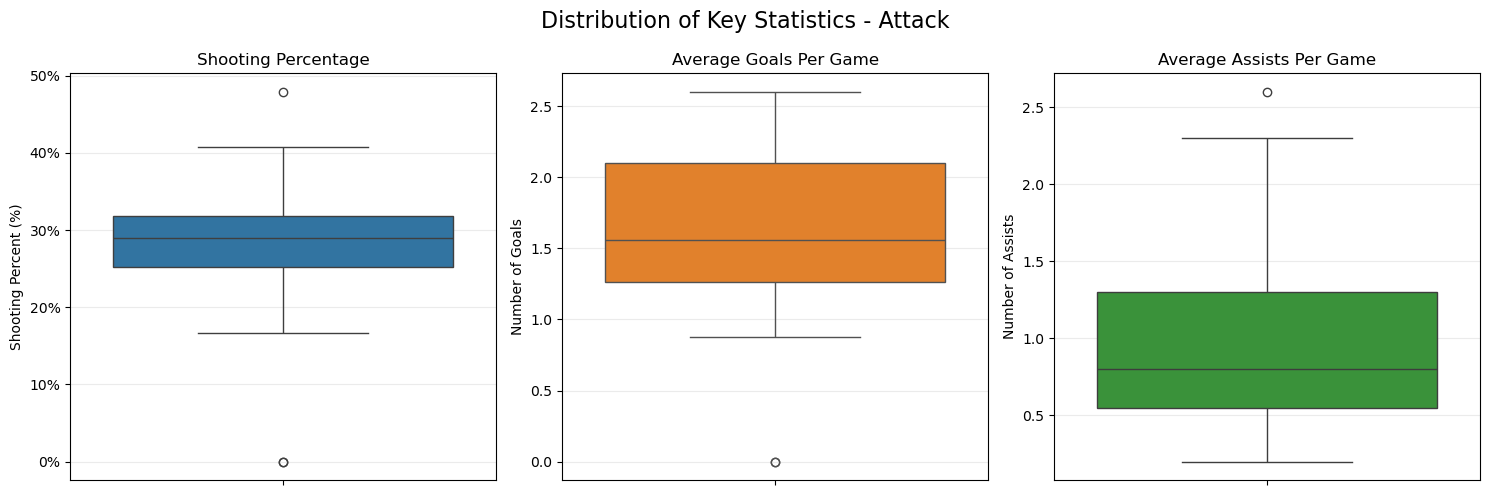

In [30]:
#attack general distribution plots

pos_1 = positional_analysis[positional_analysis["Position"]=="A"]
stat_1 = position_stats["A"]
titles_1 = ["Shooting Percentage", "Average Goals Per Game", "Average Assists Per Game"]
colors_1 = sns.color_palette()

fig_1, axes_1 = plt.subplots(1,3,figsize = (15,5))
fig_1.suptitle(f"Distribution of Key Statistics - Attack", fontsize = 16)

for AX, STAT, TITLE, color in zip(axes_1, stat_1, titles_1, colors_1):
    sns.boxplot(data =pos_1, y=STAT, ax = AX, color = color)
    AX.set_title(TITLE)
    AX.set_ylabel("")
    AX.grid(True, axis = 'y',alpha = 0.25)

axes_1[0].set_ylabel("Shooting Percent (%)")
axes_1[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes_1[1].set_ylabel("Number of Goals")
axes_1[2].set_ylabel("Number of Assists")
    
plt.tight_layout()
plt.show()

In [34]:
pos_1[["Shooting %", "Avg Goals/Game", "Avg Assists/Game"]].describe()

,Shooting %,Avg Goals/Game,Avg Assists/Game
count,31.000000,31.000000,31.000000
mean,0.276908,1.573822,0.989849
std,0.094989,0.630952,0.672237
min,0.000000,0.000000,0.200000
25%,0.252273,1.261111,0.550000
50%,0.290323,1.555556,0.800000
75%,0.318841,2.100000,1.300000
max,0.479167,2.600000,2.600000


**Analysis** <br>
Fifty percent of the attackmen have a shooting accuracy between 25.2% and 31.9%. There are two people who have a zero percent shooting accuracy, Matt Rambo and Michael Lampert. This is likely due to a low number of Shots (16 and 3, respectively) and Games Played (6 and 3, respectively). On the upper end of the box plot, Connor Shellenberger has the highest shooting accuracy at 47.9%. The average number of goals per game is 1.6 and the average number of assists per game is 1.0. Half of the players have between 1.3 and 2.1 average goals per game and between 0.6 and 1.3 average assists per game. The average of each player's goals and assists is used to accurately compare players who have played in different amounts of games. 

### Best Players By Statistic
We continue by finding the top-ranked players based on the positional statistics.

In [52]:
#set up database of just attackmen
best_attackmen = positional_analysis[positional_analysis["Position"] == "A"]

#determine each players rank wrt each of the measures
best_attack = best_attackmen.copy()
best_attack["shooting_rank"] = best_attack["Shooting %"].rank(ascending=False)
best_attack["Goals_rank"] = best_attack["Avg Goals/Game"].rank(ascending=False)
best_attack["assist_rank"]=best_attack["Avg Assists/Game"].rank(ascending=False)

#find average rank - lowest means best player - each category weighted equally
best_attack["avg_rank"]=best_attack[["shooting_rank", "Goals_rank", "assist_rank"]].mean(axis=1)

best_attack_player=best_attack.sort_values("avg_rank")
best_attack_player[["First Name", "Last Name", "Team", "Shooting %", "Avg Goals/Game", "Avg Assists/Game"]].head(10)

,First Name,Last Name,Team,Shooting %,Avg Goals/Game,Avg Assists/Game
0,Connor,Shellenberger,Atlas,0.479167,2.300000,2.300000
13,Owen,Hiltz,Chaos,0.347826,2.285714,1.571429
9,Kieran,McArdle,Waterdogs,0.365385,1.900000,1.200000
39,CJ,Kirst,Waterdogs,0.333333,2.250000,1.000000
4,Chris,Kavanagh,Redwoods,0.294872,2.300000,1.200000
10,Aidan,Carroll,Whipsnakes,0.381818,2.100000,0.800000
1,Michael,Sowers,Waterdogs,0.276923,1.800000,2.300000
8,Dylan,Molloy,Redwoods,0.298851,2.600000,0.500000
7,TJ,Malone,Whipsnakes,0.290323,1.800000,1.400000
6,Brennan,O'Neill,Outlaws,0.270588,2.300000,0.800000


To investigate the best attackmen based on the attack-specific statistics we used, I found the rank of each attackman with respect to their shooting percentage, average goals per game, and average assists per game. The average rank between the statistics is found for the overall ranking (Each category was weighted evenly).
<br>

**Analysis**

For further analysis, I added the team for each players into the table. Connor Shellenberger was Attackmen of the Year in the Lexus End of Season awards. This aligns with the findings in the table. The Atlas and the Waterdogs were very strong teams in the 2025 season. The Atlas were the number one seed in the Eastern Conference and won the PLL Playoffs in the Post-Season. The Waterdogs were the number three seed in the Eastern Conference and made it to the Semifinals in the PLL Playoffs (losing to the Atlas). According to these statistics, the Atlas had the top attackman, Connor Shellenburger, in the league. The Waterdogs had three of the top ten attackmen in the PLL, contributing to their success.

### Investigating Top Players
Look further into the top three attackmen's statistics to determine what differentiates their abilities. We investigate the proportion of their goals that are 1-point, 2-point, or assists.

In [55]:
#create connor shellenberger profile
connor_shellenberger_A = positional_analysis[(positional_analysis["First Name"] == "Connor") & (positional_analysis["Last Name"]=="Shellenberger")].iloc[0]

connor_A_values = [connor_shellenberger_A["Assists"], connor_shellenberger_A["1Pt Goals"], connor_shellenberger_A["2Pt Goals"]]
connor_A_labels = ["Assists", "One Point Goals", "Two Point Goals"]

#create owen hiltz profile
owen_hiltz_A = positional_analysis[(positional_analysis["First Name"]=="Owen")& (positional_analysis["Last Name"]=="Hiltz")].iloc[0]
owen_hiltz_A_values = [owen_hiltz_A["Assists"], owen_hiltz_A["1Pt Goals"], owen_hiltz_A["2Pt Goals"]]
owen_hiltz_A_labels = ["Assists", "One Point Goals", "Two Point Goals"]

#create Kieran McArdle
kieran_mcardle_A = positional_analysis[(positional_analysis["First Name"]=="Kieran")& (positional_analysis["Last Name"]=="McArdle")].iloc[0]
kieran_mcardle_A_values = [kieran_mcardle_A["Assists"], kieran_mcardle_A["1Pt Goals"], kieran_mcardle_A["2Pt Goals"]]
kieran_mcardle_A_labels = ["Assists", "One Point Goals", "Two Point Goals"]


#create table with overall stats
final_A_table = [["Assists (Total)", connor_A_values[0],owen_hiltz_A_values[0], kieran_mcardle_A_values[0]],
                  ["One Point Goals (Total)", connor_A_values[1], owen_hiltz_A_values[1], kieran_mcardle_A_values[1]],
                  ["Two Point Goals (Total)", connor_A_values[2], owen_hiltz_A_values[2], kieran_mcardle_A_values[2]],
                  ["Shots On Goal Percentage", connor_shellenberger_A["Shots On Goal %"], owen_hiltz_A["Shots On Goal %"], kieran_mcardle_A["Shots On Goal %"]]]

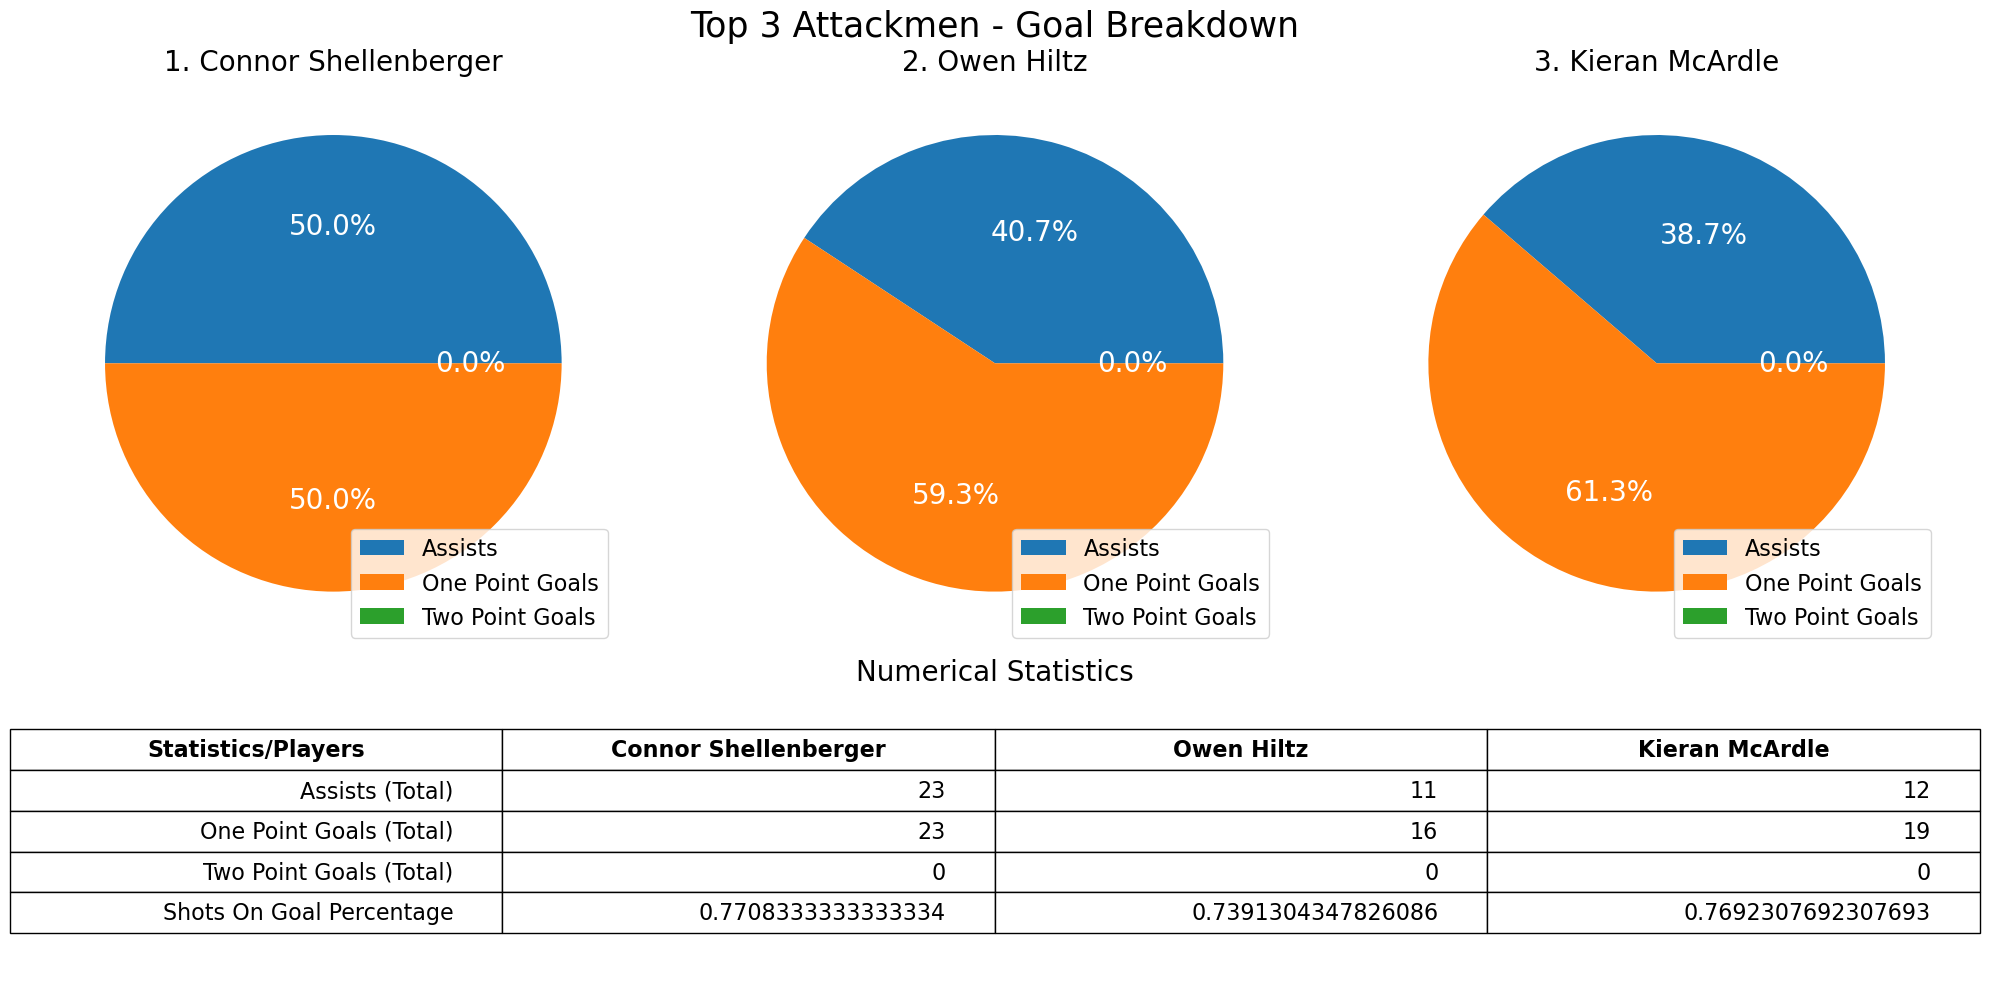

In [69]:
#generating the plots
fig_CSA, axes=plt.subplot_mosaic(
    [["CSA1", "CSA2", "CSA3"],
     ["CSA4", "CSA4", "CSA4"]], 
    figsize=(20,10),
    height_ratios=[2,1]
)

fig_CSA.suptitle("Top 3 Attackmen - Goal Breakdown",fontsize=25)
axes["CSA1"].pie(connor_A_values, autopct ='%1.1f%%', textprops={"fontsize":20, "color":"white"})
axes["CSA1"].set_title("1. Connor Shellenberger", fontsize=20)
axes["CSA1"].legend(labels = connor_A_labels, loc = "lower right",fontsize=16)

axes["CSA2"].pie(owen_hiltz_A_values, autopct ='%1.1f%%', textprops={"fontsize":20, "color":"white"})
axes["CSA2"].set_title("2. Owen Hiltz",fontsize=20)
axes["CSA2"].legend(labels = owen_hiltz_A_labels, loc = "lower right",fontsize=16)

axes["CSA3"].pie(kieran_mcardle_A_values,autopct ='%1.1f%%', textprops={"fontsize":20, "color":"white"})
axes["CSA3"].set_title("3. Kieran McArdle",fontsize=20)
axes["CSA3"].legend(labels = kieran_mcardle_A_labels, loc = "lower right",fontsize=16)

axes["CSA4"].axis("off")
connor_A_table_ = axes["CSA4"].table(cellText=final_A_table, colLabels = ["Statistics/Players", "Connor Shellenberger", "Owen Hiltz", "Kieran McArdle"], loc="center")
connor_A_table_.set_fontsize(16)
connor_A_table_.scale(1,2)
axes["CSA4"].set_title("Numerical Statistics",fontsize=20)
for (row, col), cell in connor_A_table_.get_celld().items():
    if row == 0:  # header row
        cell.set_text_props(fontweight='bold')

plt.tight_layout()
plt.show()

**Analysis**
<br>
It appears that the top three attackmen have near equal amounts of one-point goals and assists. This indicates a strong ability to work with their teammates to set up plays, as opposed to attempting to score alone the majority of the time. It is also noted that none of the players scored any 2-point goals. This highlights their preference and skill at close ranges on teh field. It demonstrates their unique specialization as an attackmen, who generally focus on close-up shots and plays.

## Midfielder Analysis

### General Distribution of Statistics

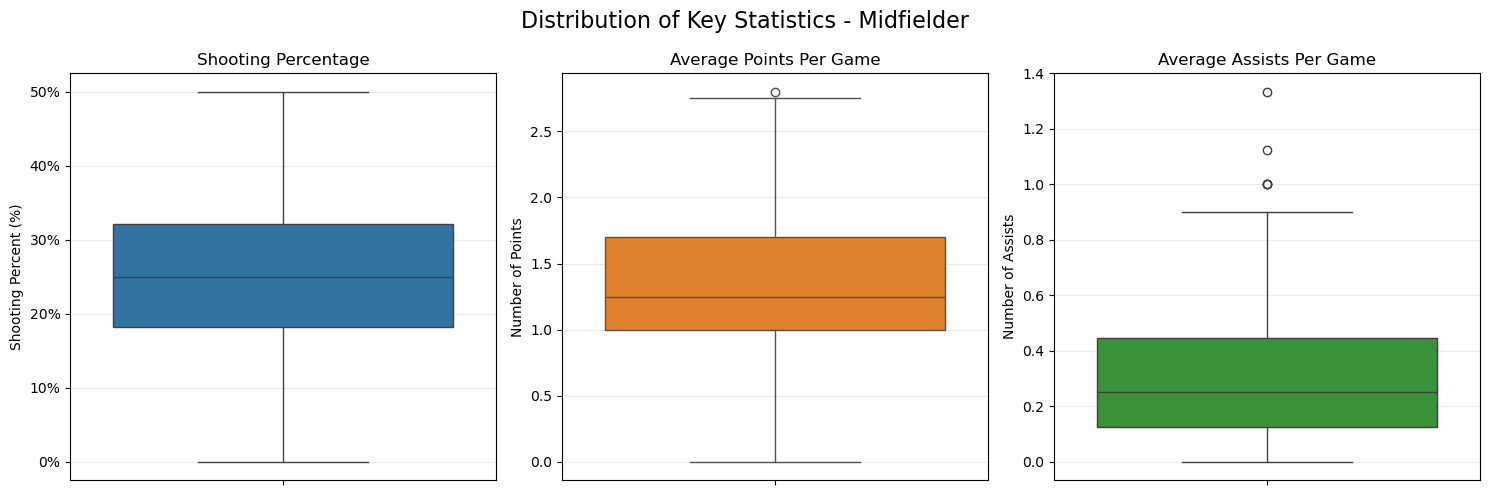

In [61]:
#midfielder plot generation

pos_2 = positional_analysis[positional_analysis["Position"]=="M"]
stat_2 = position_stats["M"]
titles_2 = ["Shooting Percentage", "Average Points Per Game", "Average Assists Per Game"]
colors_1 = sns.color_palette()

fig_2, axes_2 = plt.subplots(1,3,figsize = (15,5))
fig_2.suptitle(f"Distribution of Key Statistics - Midfielder", fontsize = 16)

for AX, STAT, TITLE, color in zip(axes_2, stat_2, titles_2, colors_1):
    sns.boxplot(data =pos_2, y=STAT, ax = AX, color = color)
    AX.set_title(TITLE)
    AX.set_ylabel("")
    AX.grid(True, axis = 'y',alpha = 0.25)

axes_2[0].set_ylabel("Shooting Percent (%)")
axes_2[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes_2[1].set_ylabel("Number of Points")
axes_2[2].set_ylabel("Number of Assists")

plt.tight_layout()
plt.show()

In [63]:
pos_2[["Shooting %", "Avg Points/Game", "Avg Assists/Game"]].describe()

,Shooting %,Avg Points/Game,Avg Assists/Game
count,49.000000,49.000000,49.000000
mean,0.255244,1.352551,0.360658
std,0.115722,0.621935,0.335466
min,0.000000,0.000000,0.000000
25%,0.181818,1.000000,0.125000
50%,0.250000,1.250000,0.250000
75%,0.321429,1.700000,0.444444
max,0.500000,2.800000,1.333333


**Analysis**
<br>
There are significantly more midfielder players than attackmen (49 vs 31) who have played at least three games. The average shooting percentage is 25.5%, average average points per game is 1.4, and average average assists per game is 0.4. The average number of assists per game is skewed towards the lower end, with 75% of players having less than 0.5 assists, on average, per game. This describes the role of a midfielder because they are in charge of transitions and bringing the ball towards the attack's end of the field. Hence, they set up the offensive plays without necessarily taking part in the action.

### Best Players By Statistic
We continue by finding the top-ranked players based on the positional statistics.

In [70]:
#set up database of just midis
best_midi = positional_analysis[positional_analysis["Position"]=="M"]

#determine each players rank wrt each of the measures
best_midi_offense = best_midi.copy()
best_midi_offense["shooting_rank"]=best_midi_offense["Shooting %"].rank(ascending=False)
best_midi_offense["points_rank"]=best_midi_offense["Avg Points/Game"].rank(ascending=False)
best_midi_offense["assists_rank"]=best_midi_offense["Avg Assists/Game"].rank(ascending=False)

#find average rank - each weighted equally - lowest is best player
best_midi_offense["avg_rank"] = best_midi_offense[["shooting_rank", "points_rank", "assists_rank"]].mean(axis=1)

best_mid=best_midi_offense.sort_values("avg_rank")
best_mid[["First Name", "Last Name", "Team", "Avg Points/Game", "Avg Assists/Game", "Shooting %"]].head(10)

,First Name,Last Name,Team,Avg Points/Game,Avg Assists/Game,Shooting %
18,Andrew,McAdorey,Redwoods,2.400000,0.900000,0.341463
12,Matt,Campbell,Cannons,2.800000,0.800000,0.285714
46,Shane,Knobloch,Chaos,2.750000,1.000000,0.272727
21,Jared,Bernhardt,Outlaws,2.444444,0.444444,0.339623
42,Reid,Bowering,Atlas,1.857143,0.428571,0.500000
32,Dalton,Young,Outlaws,1.700000,0.600000,0.440000
26,Ross,Scott,Chaos,2.000000,0.800000,0.315789
14,Matt,Brandau,Whipsnakes,2.500000,0.300000,0.379310
25,Ryan,Drenner,Cannons,2.000000,0.200000,0.461538
28,Matt,Traynor,Atlas,2.000000,0.800000,0.230769


To investigate the best midfielder based on the positional statistics we used, I found the rank of each midfielder with respect to their average points per game, average assists per game, and shooting percentage. The average rank between the statistics is found for the overall ranking (Each category was weighted evenly).
<br>
**Analysis**
<br>

Andrew McAdorey is statistically considered the best midfielder of 2025, with Matt Campbell close behind. Matt Campbell won Midfielder of the Year in the Lexus End of Season Awards 2025, so our analysis accurately reflects industry standards. Another notable aspect of the ranking is Andrew McAdorey and Matt Brandau are the only players who were not on the Cannons, Chaos, Atlas, or Outlaws. They played on the Redwoods and Whipsnakes, respectively.

### Investigating Top Players
Look further into the top three midfielder's statistics to determine what differentiates their abilities. Midfielder's tend to play a more offensive role, so offensive statistics are used.

In [74]:
#create matt campbell profile
matt_campbell_M = positional_analysis[(positional_analysis["First Name"]=="Matt") & (positional_analysis["Last Name"]=="Campbell")].iloc[0]
matt_campbell_values = [matt_campbell_M["2Pt Shots On Goal"], matt_campbell_M["1Pt Shots On Goal"]]
midi_labels = ["2 Point Shots On Goal", "1 Point Shots On Goal"]


#create shane knobloch profile
shane_knobloch_M = positional_analysis[(positional_analysis["First Name"]=="Shane") & (positional_analysis["Last Name"]=="Knobloch")].iloc[0]
shane_knobloch_values = [shane_knobloch_M["2Pt Shots On Goal"], shane_knobloch_M["1Pt Shots On Goal"]]

#create reid bowering profile
reid_bowering_M = positional_analysis[(positional_analysis["First Name"]=="Reid") & (positional_analysis["Last Name"]=="Bowering")].iloc[0]
reid_bowering_values = [reid_bowering_M["2Pt Shots On Goal"], reid_bowering_M["1Pt Shots On Goal"]]

#create jared bernhardt profile
jared_bernhardt_M = positional_analysis[(positional_analysis["First Name"]=="Jared") & (positional_analysis["Last Name"]=="Bernhardt")].iloc[0]
jared_bernhardt_values = [jared_bernhardt_M["2Pt Shots On Goal"], jared_bernhardt_M["1Pt Shots On Goal"]]

#create andrew mcadorey profile
andrew_mcadorey_M = positional_analysis[(positional_analysis["First Name"] == "Andrew") & (positional_analysis["Last Name"] == "McAdorey")].iloc[0]
andrew_mcadorey_values = [andrew_mcadorey_M["2Pt Shots On Goal"], andrew_mcadorey_M["1Pt Shots On Goal"]]

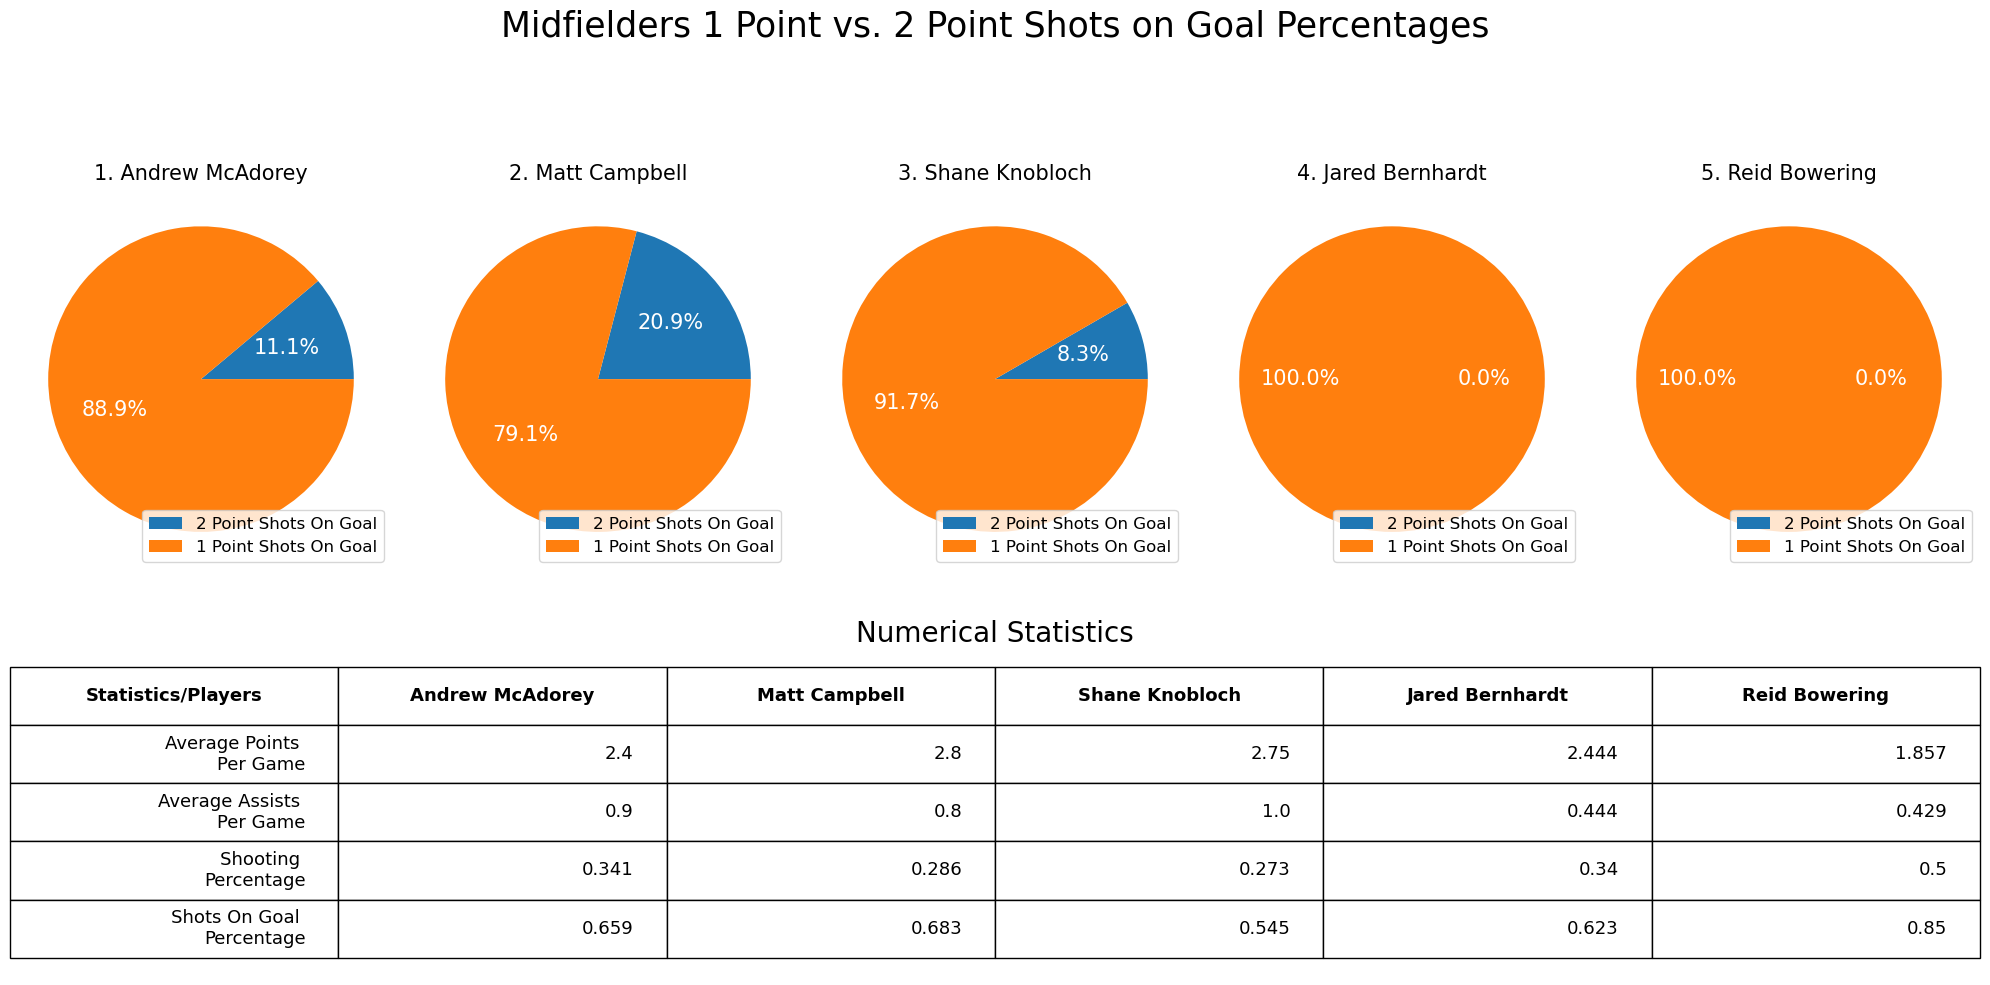

In [81]:
fig_M, ax_M = plt.subplot_mosaic(
    [["M1", "M2", "M3", "M4", "M5"],
     ["M6","M6", "M6", "M6", "M6"]], figsize=(20,10),height_ratios=[2,1])


fig_M.suptitle("Midfielders 1 Point vs. 2 Point Shots on Goal Percentages", fontsize=25)
ax_M["M1"].pie(andrew_mcadorey_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_M["M1"].set_title("1. Andrew McAdorey", fontsize=15)
ax_M["M1"].legend(labels=midi_labels, loc="lower right", fontsize=12)

ax_M["M2"].pie(matt_campbell_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_M["M2"].set_title("2. Matt Campbell", fontsize=15)
ax_M["M2"].legend(labels=midi_labels, loc="lower right", fontsize=12)

ax_M["M3"].pie(shane_knobloch_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_M["M3"].set_title("3. Shane Knobloch", fontsize=15)
ax_M["M3"].legend(labels=midi_labels, loc='lower right', fontsize=12)

ax_M["M4"].pie(jared_bernhardt_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_M["M4"].set_title("4. Jared Bernhardt", fontsize=15)
ax_M["M4"].legend(labels=midi_labels, loc='lower right', fontsize=12)

ax_M["M5"].pie(reid_bowering_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_M["M5"].set_title("5. Reid Bowering", fontsize=15)
ax_M["M5"].legend(labels=midi_labels, loc='lower right', fontsize=12)


#chose to round the percentages to 2 decimal points for clear table
final_M_table = [["Average Points \nPer Game", andrew_mcadorey_M["Avg Points/Game"], matt_campbell_M["Avg Points/Game"], shane_knobloch_M["Avg Points/Game"], jared_bernhardt_M["Avg Points/Game"].round(3), reid_bowering_M["Avg Points/Game"].round(3) ],
                  ["Average Assists \nPer Game", andrew_mcadorey_M["Avg Assists/Game"], matt_campbell_M["Avg Assists/Game"], shane_knobloch_M["Avg Assists/Game"], jared_bernhardt_M["Avg Assists/Game"].round(3), reid_bowering_M["Avg Assists/Game"].round(3)],
                 ["Shooting \nPercentage", andrew_mcadorey_M["Shooting %"].round(3), matt_campbell_M["Shooting %"].round(3), shane_knobloch_M["Shooting %"].round(3), jared_bernhardt_M["Shooting %"].round(3),reid_bowering_M["Shooting %"].round(3) ],
                  ["Shots On Goal \nPercentage", andrew_mcadorey_M["Shots On Goal %"].round(3), matt_campbell_M["Shots On Goal %"].round(3), shane_knobloch_M["Shots On Goal %"].round(3), jared_bernhardt_M["Shots On Goal %"].round(3), reid_bowering_M["Shots On Goal %"].round(3)]]


ax_M["M6"].axis("off")
midi_table_ = ax_M["M6"].table(cellText=final_M_table, colLabels = ["Statistics/Players", "Andrew McAdorey", "Matt Campbell", "Shane Knobloch", "Jared Bernhardt", "Reid Bowering"], loc="center")
midi_table_.auto_set_font_size(False)
midi_table_.set_fontsize(13)
midi_table_.scale(1,2.5)
ax_M["M6"].set_title("Numerical Statistics",fontsize=20)

for (row, col), cell in midi_table_.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold')

plt.tight_layout()
plt.show()

**Analysis**
<br>
Midfielders have access to the entire field during games, so I wanted to investigate whether it impacted the type of shots they take. Two-point shots are taken from further away from the goal. I used Shots On Goal instead of Shots to compare these numbers because Shots On Goal typically indicates a legitimate attempt to gain points, instead of a last-minute attempt to shoot at the end of a quarter. It is clear that midfielders take more two-point shots than attackmen, but they still focus on gaining points using close-range tactics (one point shots). The table also indicates that the majority of the top five players' shots are on-goal, so they are good at determining when there are shot opportunities.

## Long Stick Midfielder and Short Stick Defensive Midfielder Analysis
In this positional analysis, I decided to combine long stick midfielders and short stick defensive midfielders. They are both defensive roles and use the same statistics. The general distributions are still done by individual role to avoid excessive outliers.

### General Distribution of Statistics - Long Stick Midfielder

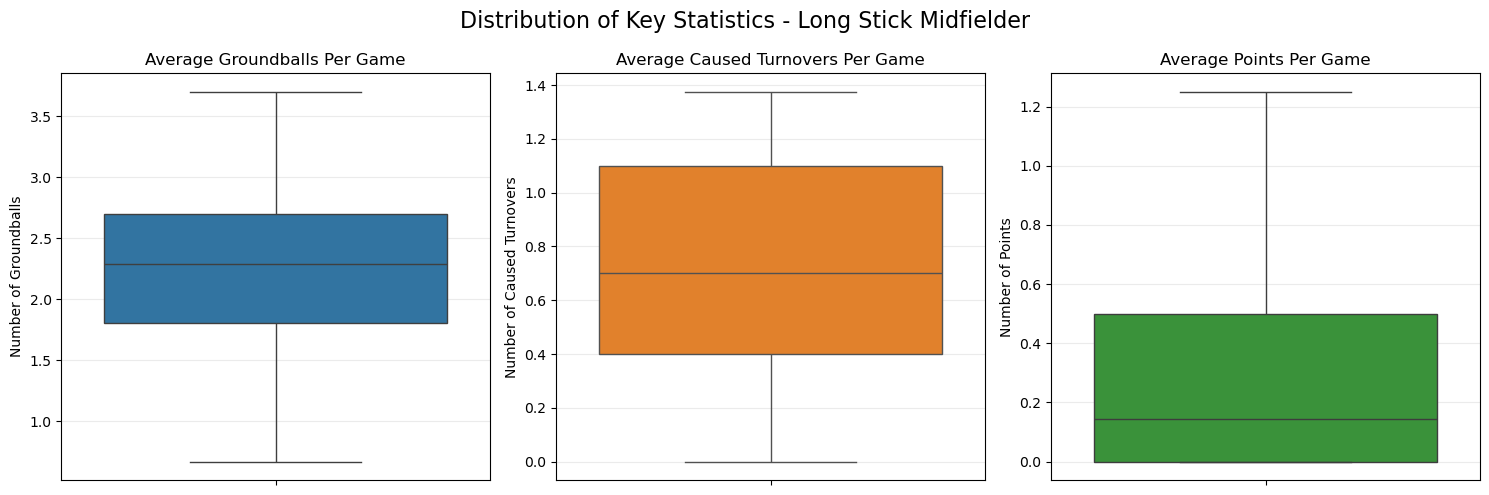

In [84]:
#long stick midfielder plots

pos_3 = positional_analysis[positional_analysis["Position"]=="LSM"]
stat_3 = position_stats["LSM"]
titles_3 = ["Average Groundballs Per Game", "Average Caused Turnovers Per Game", "Average Points Per Game"]
colors_1 = sns.color_palette()

fig_3, axes_3 = plt.subplots(1,3,figsize = (15,5))
fig_3.suptitle(f"Distribution of Key Statistics - Long Stick Midfielder", fontsize = 16)

for AX, STAT, TITLE, color in zip(axes_3, stat_3, titles_3, colors_1):
    sns.boxplot(data =pos_3, y=STAT, ax = AX, color = color)
    AX.set_title(TITLE)
    AX.set_ylabel("")
    AX.grid(True, axis = 'y',alpha = 0.25)

axes_3[0].set_ylabel("Number of Groundballs")
axes_3[1].set_ylabel("Number of Caused Turnovers")
axes_3[2].set_ylabel("Number of Points")

plt.tight_layout()
plt.show()

In [85]:
pos_3[["Avg Groundballs/Game", "Avg CT/Game", "Avg Points/Game"]].describe()

,Avg Groundballs/Game,Avg CT/Game,Avg Points/Game
count,17.000000,17.000000,17.000000
mean,2.264846,0.730042,0.346639
std,0.823653,0.437739,0.411568
min,0.666667,0.000000,0.000000
25%,1.800000,0.400000,0.000000
50%,2.285714,0.700000,0.142857
75%,2.700000,1.100000,0.500000
max,3.700000,1.375000,1.250000


**Analysis**
<br>
There is an approximately symmetric distribution of average groundballs per game, which suggests the average number of groundballs per game is more reliant on the amount of time the players have played. There is also approximately symmetric distribution of average caused turnovers per game. The average points per game is strongly skewed to the lower end of the scale. This reinforces the defensive role of the long-stick midfielders. 

### General Distribution of Statistics - Short Stick Defensive Midfielder

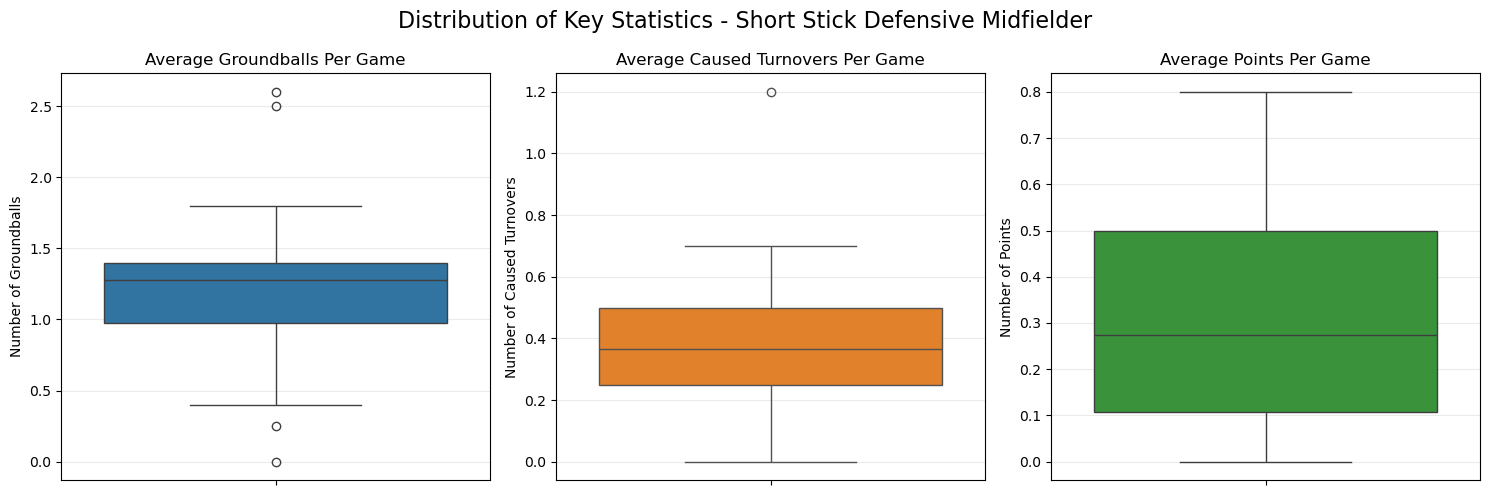

In [87]:
#short stick defense midfielder plots

pos_4 = positional_analysis[positional_analysis["Position"]=="SSDM"]
stat_4 = position_stats["SSDM"]
titles_4 = ["Average Groundballs Per Game", "Average Caused Turnovers Per Game", "Average Points Per Game"]
colors_1 = sns.color_palette()

fig_4, axes_4 = plt.subplots(1,3,figsize = (15,5))
fig_4.suptitle(f"Distribution of Key Statistics - Short Stick Defensive Midfielder", fontsize = 16)

for AX, STAT, TITLE, color in zip(axes_4, stat_4, titles_4, colors_1):
    sns.boxplot(data =pos_4, y=STAT, ax = AX, color = color)
    AX.set_title(TITLE)
    AX.set_ylabel("")
    AX.grid(True, axis = 'y',alpha = 0.25)

axes_4[0].set_ylabel("Number of Groundballs")
axes_4[1].set_ylabel("Number of Caused Turnovers")
axes_4[2].set_ylabel("Number of Points")

plt.tight_layout()
plt.show()

In [88]:
pos_4[["Avg Groundballs/Game", "Avg CT/Game", "Avg Points/Game"]].describe()

,Avg Groundballs/Game,Avg CT/Game,Avg Points/Game
count,28.000000,28.000000,28.000000
mean,1.233036,0.386806,0.293651
std,0.550588,0.246158,0.227211
min,0.000000,0.000000,0.000000
25%,0.972222,0.250000,0.108333
50%,1.275000,0.366667,0.275000
75%,1.400000,0.500000,0.500000
max,2.600000,1.200000,0.800000


**Analysis**<br>
The majority of short stick defensive midfielders get between 1.0 and 1.4 groundballs, on average, per game. This is lower than the range for long stick midfielders. Additionally, the range for caused turnovers is less than that for long stick midfielders. Hence, they are less likely to be involved directly in transitions across the field because these statistics directly relate to transitions. The average points per game distribution is approximately symmetrical as well, which indicates the short stick defensive midfielders are still somewhat involved in offensive strategies.

### Best Players By Statistic
To determine the best defensive midfielder (after combining long stick midfielders and short stick defensive midfielders into one group), a similar formula to the previous positions is used. Each statistic is weighted evenly.

In [90]:
#Combine the LSM and SSDM into one category

defensive_midi_analysis = positional_analysis[positional_analysis["Position"].isin(["LSM", "SSDM"])]

#determining best D midi - weighted all three statistics equally
def_midi = defensive_midi_analysis.copy()
def_midi["groundball_rank"]=defensive_midi_analysis["Avg Groundballs/Game"].rank(ascending=False)
def_midi["CT_rank"] = defensive_midi_analysis["Avg CT/Game"].rank(ascending = False)
def_midi["Avg_pts_rank"] = defensive_midi_analysis["Avg Points/Game"].rank(ascending=False)
def_midi["Avg_rank"]=def_midi[["groundball_rank", "CT_rank", "Avg_pts_rank"]].mean(axis=1)

best_def_midi = def_midi.sort_values("Avg_rank")
best_def_midi[["First Name", "Last Name", "Team","Position", "Avg Groundballs/Game", "Avg CT/Game", "Avg Points/Game"]].head(10)

,First Name,Last Name,Team,Position,Avg Groundballs/Game,Avg CT/Game,Avg Points/Game
43,Jake,Piseno,Outlaws,LSM,3.40,1.20,1.20
51,Michael,Grace,Atlas,LSM,2.25,0.75,1.25
69,Ben,Wayer,Waterdogs,LSM,2.70,0.70,0.60
88,Brian,Tevlin,Redwoods,SSDM,2.50,1.20,0.40
62,Mason,Woodward,Archers,LSM,2.30,0.60,0.80
77,Owen,Grant,Cannons,LSM,1.60,1.10,0.50
86,Jared,Conners,Redwoods,LSM,2.50,0.60,0.40
79,Zach,Geddes,Outlaws,SSDM,1.70,0.70,0.50
127,Troy,Reh,Chaos,LSM,3.70,1.10,0.10
117,Tyler,Carpenter,Atlas,LSM,2.80,0.70,0.20


**Analysis**<br>
Jake Piseno won Long Stick Midfielder of the Year at the Lexus End of Season Awards. This aligns with the rankings found statistically. There is a fairly even distribution of the top players between teams. I added the specific position into the table to see if there was an even distribution of LSM and SSDM's. Despite having a higher number of SSDMs (28 players vs 17 players), the LSMs dominate the top rankings. Hence, it is suggested that different statistics are used to rank short stick defensive midfielders in further studies.

### Investigating Top Players
Investigate the distribution of turnovers vs caused turnovers. This is a key statistic for defensive players and demonstrates their ability to play both ways across the field.

In [91]:
#create jake piseno profile
jake_piseno_M = positional_analysis[(positional_analysis["First Name"]=="Jake") & (positional_analysis["Last Name"]=="Piseno")].iloc[0]
jake_piseno_values = [jake_piseno_M["Turnovers"], jake_piseno_M["Caused Turnovers"]]
def_midi_labels = ["Turnovers", "Caused Turnovers"]

#create michael grace profile
michael_grace_M = positional_analysis[(positional_analysis["First Name"]=="Michael") & (positional_analysis["Last Name"]=="Grace")].iloc[0]
michael_grace_values = [michael_grace_M["Turnovers"], michael_grace_M["Caused Turnovers"]]

#create ben wayer profile
ben_wayer_M = positional_analysis[(positional_analysis["First Name"]=="Ben") & (positional_analysis["Last Name"]=="Wayer")].iloc[0]
ben_wayer_values = [ben_wayer_M["Turnovers"], ben_wayer_M["Caused Turnovers"]]

#create brian tevlin profile
brian_tevlin_M = positional_analysis[(positional_analysis["First Name"]=="Brian") & (positional_analysis["Last Name"]=="Tevlin")].iloc[0]
brian_tevlin_values = [brian_tevlin_M["Turnovers"], brian_tevlin_M["Caused Turnovers"]]

#create mason woodward profile
mason_woodward_M = positional_analysis[(positional_analysis["First Name"]=="Mason") & (positional_analysis["Last Name"]=="Woodward")].iloc[0]
mason_woodward_values = [mason_woodward_M["Turnovers"], mason_woodward_M["Caused Turnovers"]]

#create owen grant profile
owen_grant_M = positional_analysis[(positional_analysis["First Name"]=="Owen") & (positional_analysis["Last Name"]=="Grant")].iloc[0]
owen_grant_values = [owen_grant_M["Turnovers"], owen_grant_M["Caused Turnovers"]]

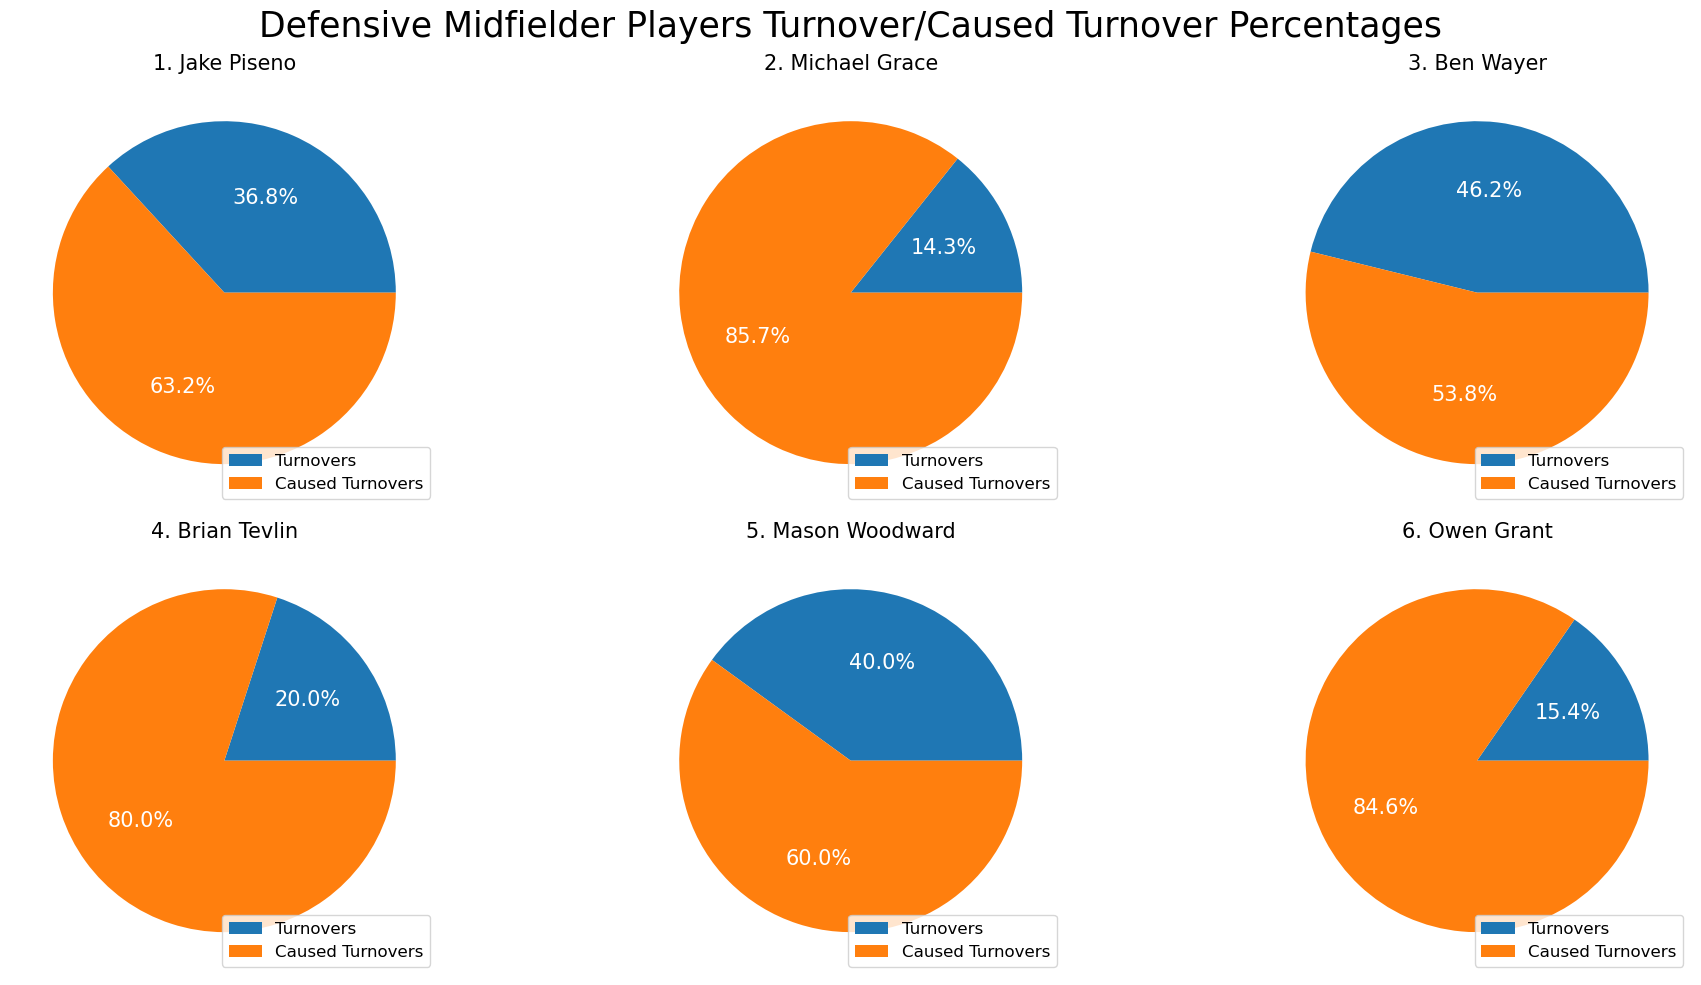

In [96]:
fig_DM, ax_DM = plt.subplots(2,3, figsize=(20,10))

fig_DM.suptitle("Defensive Midfielder Players Turnover/Caused Turnover Percentages",fontsize=25)

ax_DM[0,0].pie(jake_piseno_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_DM[0,0].set_title("1. Jake Piseno", fontsize=15)
ax_DM[0,0].legend(labels=def_midi_labels, loc="lower right", fontsize=12)

ax_DM[0,1].pie(michael_grace_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_DM[0,1].set_title("2. Michael Grace", fontsize=15)
ax_DM[0,1].legend(labels=def_midi_labels, loc="lower right", fontsize=12)

ax_DM[0,2].pie(ben_wayer_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_DM[0,2].set_title("3. Ben Wayer", fontsize=15)
ax_DM[0,2].legend(labels=def_midi_labels, loc='lower right', fontsize=12)

ax_DM[1,0].pie(brian_tevlin_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_DM[1,0].set_title("4. Brian Tevlin", fontsize=15)
ax_DM[1,0].legend(labels=def_midi_labels, loc='lower right', fontsize=12)

ax_DM[1,1].pie(mason_woodward_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_DM[1,1].set_title("5. Mason Woodward", fontsize=15)
ax_DM[1,1].legend(labels=def_midi_labels, loc='lower right', fontsize=12)

ax_DM[1,2].pie(owen_grant_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_DM[1,2].set_title("6. Owen Grant", fontsize=15)
ax_DM[1,2].legend(labels=def_midi_labels, loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

**Analysis**<br>
Note that Mason Woodward is an SSDM. The other players are LSM's. There is a fair variety of proportions of turnovers to caused turnovers. Despite the slight variation, caused turnovers is in the majority, which highlights the primarily defensive role of SSDM's and LSM's. 

## Defense Analysis
Defense players use long sticks and are typically coordinated by the Goalie. Their role is to prevent the attackment from scoring.

## General Distribution of Statistics
Defensemen are rated differently than other positions. They are commonly assessed based on a statistic called "Lockdown Rating." Lockdown Ratings track the scoring and shooting output of the primary opposing attacker when matched up head-to-head with a defenseman. This statistic is not included in our dataset. There are not publicly available sources to calculate it. Hence, we note the difference and continue our investigation. 

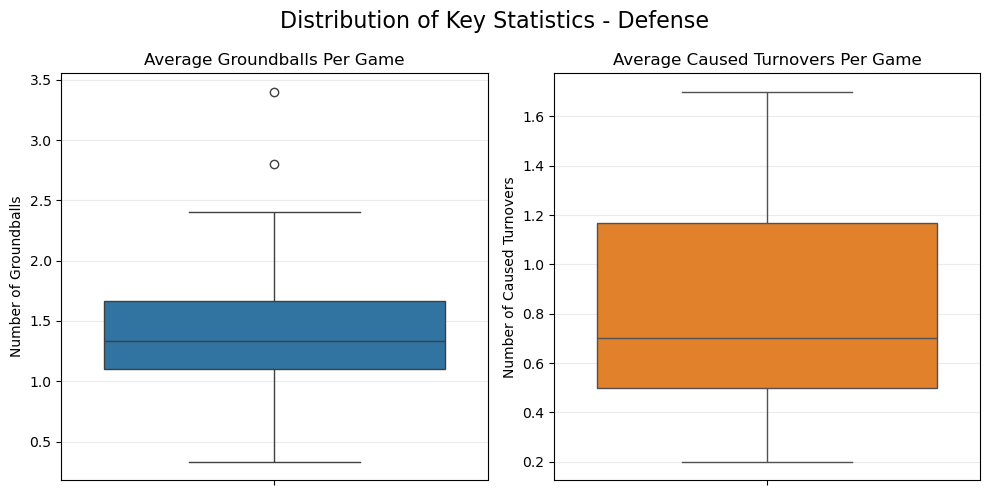

In [150]:
pos_7 = positional_analysis[positional_analysis["Position"]=="D"]
stat_7=position_stats["D"]
titles_7 = ["Average Groundballs Per Game", "Average Caused Turnovers Per Game"]
colors_1 = sns.color_palette()

fig_7, axes_7=plt.subplots(1,2,figsize=(10,5))
fig_7.suptitle("Distribution of Key Statistics - Defense", fontsize=16)


for AX, STAT, TITLE, color in zip(axes_7, stat_7, titles_7, colors_1):
    sns.boxplot(data =pos_7, y=STAT, ax = AX, color = color)
    AX.set_title(TITLE)
    AX.set_ylabel("")
    AX.grid(True, axis = 'y',alpha = 0.25)

axes_7[0].set_ylabel("Number of Groundballs")
axes_7[1].set_ylabel("Number of Caused Turnovers")

plt.tight_layout()
plt.show()

In [151]:
pos_7[["Avg Groundballs/Game", "Avg CT/Game"]].describe()

,Avg Groundballs/Game,Avg CT/Game
count,29.000000,29.000000
mean,1.459770,0.805460
std,0.669144,0.387444
min,0.333333,0.200000
25%,1.100000,0.500000
50%,1.333333,0.700000
75%,1.666667,1.166667
max,3.400000,1.700000


**Analysis** <br>
There is a range of 3.1 in the average groundballs per game. This large range indicates how involved individual players are in the transitions from offense to defense. The distribution of average caused turnovers per game is skewed towards the lower end. Since the defensemen operate in coordinated strategies more often than other player positions, the low number of caused turnovers per player could be a marker of this strategy.

### Best Player By Statistic
The top players are ranked using a similar method to previous positions. However, it is important to acknowledge that these rankings are inaccurate to industry results due to a limited dataset.

In [152]:
#create positional database
best_defense = positional_analysis[positional_analysis["Position"]=="D"]

#find rank of each player per statistic
top_defense = best_defense.copy()
top_defense["gb_rank"]=top_defense["Avg Groundballs/Game"].rank(ascending=False)
top_defense["ct_rank"]=top_defense["Avg CT/Game"].rank(ascending=False)

#find avg rank -lower is better - evenly rated criteria
top_defense["avg_rank"]=top_defense[["gb_rank", "ct_rank"]].mean(axis=1)
top_D = top_defense.sort_values("avg_rank")
top_D[["First Name", "Last Name", "Team", "Avg Groundballs/Game", "Avg CT/Game"]].head(10)


,First Name,Last Name,Team,Avg Groundballs/Game,Avg CT/Game
126,Graeme,Hossack,Archers,2.400000,1.400000
125,Ben,Randall,Waterdogs,2.100000,1.300000
132,Ajax,Zappitello,Whipsnakes,1.600000,1.700000
95,Brett,Makar,Atlas,2.333333,0.888889
121,Kenny,Brower,Waterdogs,1.625000,1.125000
104,Michael,Rexrode,Atlas,1.400000,1.200000
157,Garrett,Epple,Cannons,1.400000,1.200000
138,Brendan,Lavelle,Archers,3.400000,0.600000
73,Michael,Manley,Outlaws,1.900000,0.700000
89,Jimmy,Freehill,Waterdogs,1.666667,0.777778


**Analysis**<br>
Gavin Adler won the Defenseman of the Year in the Lexus End of Season Awards, but he is not in the top ten players. This difference is attributed to the limited dataset and lack of defensemen-specific statistics. In the top 10 defenesemen rankings above, the Waterdogs have three players and the Archers and Atlas have two. This aligns with the strength of these teams during the 2025 Regular Season.

### Investigating Top Players
To look into the top defensemen, I chose to investigate the percentage of turnovers to caused turnovers for each of the top three defensemen.

In [153]:
#create graeme hossack
hossack_D=positional_analysis[(positional_analysis["First Name"]=="Graeme") & (positional_analysis["Last Name"]=="Hossack")].iloc[0]
hossack_values = [hossack_D["Turnovers"], hossack_D["Caused Turnovers"]]
def_defense_labels = ["Turnovers", "Caused Turnovers"]

#ben randall
randall_D=positional_analysis[(positional_analysis["First Name"]=="Ben") & (positional_analysis["Last Name"]=="Randall")].iloc[0]
randall_values = [randall_D["Turnovers"],randall_D["Caused Turnovers"]]

#ajax zappitello
zappitello_D=positional_analysis[(positional_analysis["First Name"]=="Ajax") & (positional_analysis["Last Name"]=="Zappitello")].iloc[0]
zappitello_values = [zappitello_D["Turnovers"], zappitello_D["Caused Turnovers"]]

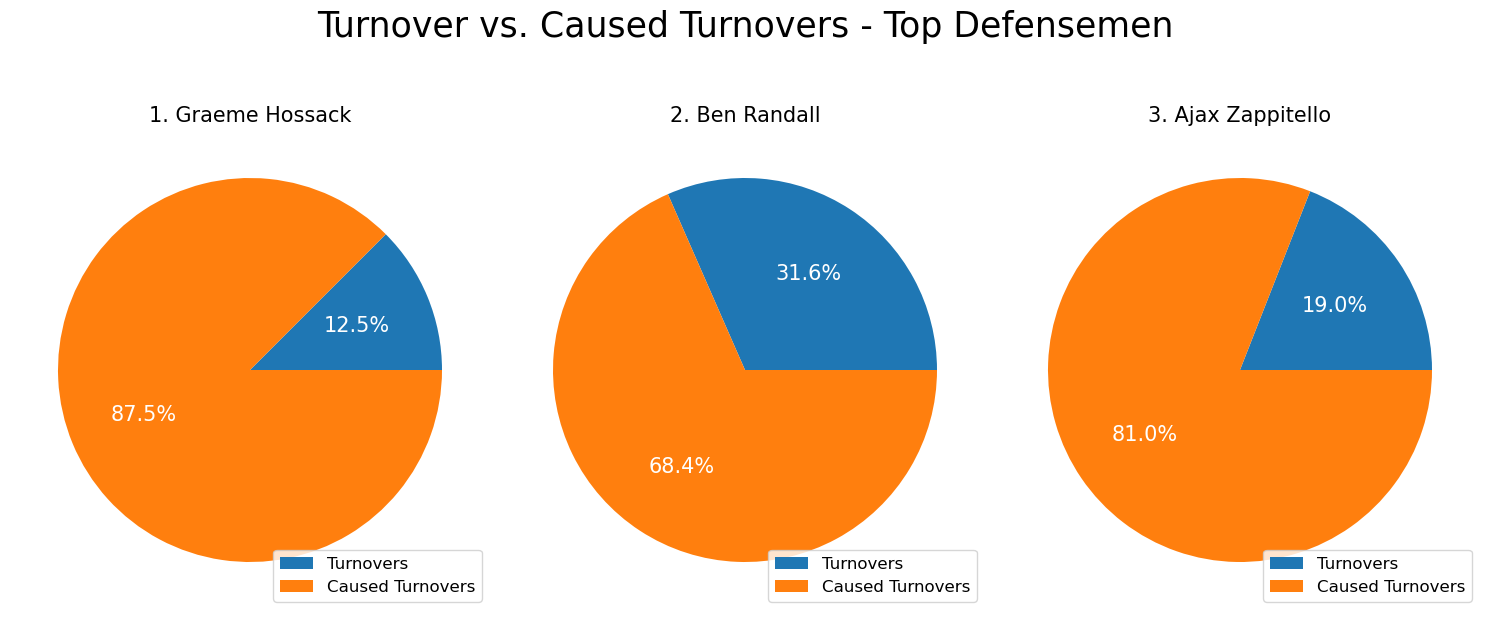

In [159]:
fig_Def, ax_Def = plt.subplots(1,3, figsize=(15,7))

fig_Def.suptitle("Turnover vs. Caused Turnovers - Top Defensemen",fontsize=25)

ax_Def[0].pie(hossack_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_Def[0].set_title("1. Graeme Hossack", fontsize=15)
ax_Def[0].legend(labels=def_defense_labels, loc="lower right", fontsize=12)

ax_Def[1].pie(randall_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_Def[1].set_title("2. Ben Randall", fontsize=15)
ax_Def[1].legend(labels=def_defense_labels, loc="lower right", fontsize=12)

ax_Def[2].pie(zappitello_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_Def[2].set_title("3. Ajax Zappitello", fontsize=15)
ax_Def[2].legend(labels=def_defense_labels, loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

**Analysis**<br>
As a defensive player, it is expected to see a higher proportion of caused turnovers. The top three players, according to the earlier rankings, cause the majority of turnovers they participate in. This is a positive statistic for defensemen and is commonly used to analyze their skills.

## Faceoff Analysis
Faceoff players are commonly known as "face-off, get-off" players. They begin each quarter and plays after goals. Faceoff players have their own specific statistics, used below.

### General Distribution of Statistics

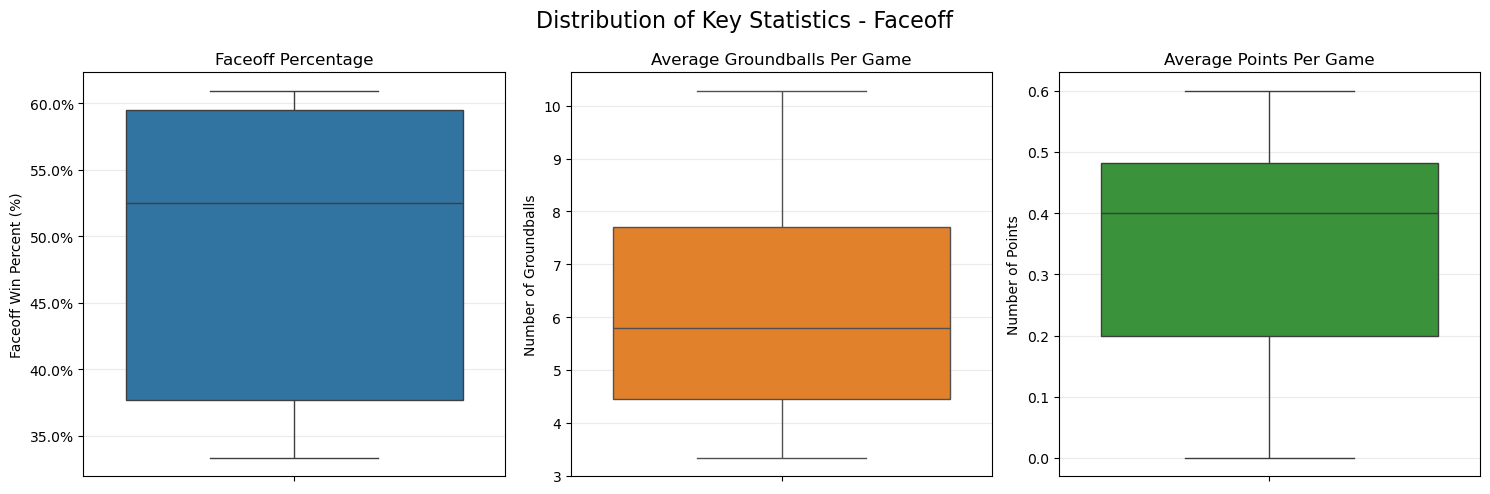

In [163]:
#faceoff plots

pos_5 = positional_analysis[positional_analysis["Position"]=="FO"]
stat_5 = position_stats["FO"]
titles_5 = ["Faceoff Percentage", "Average Groundballs Per Game", "Average Points Per Game"]
colors_1 = sns.color_palette()

fig_5, axes_5 = plt.subplots(1,3,figsize = (15,5))
fig_5.suptitle(f"Distribution of Key Statistics - Faceoff", fontsize = 16)

for AX, STAT, TITLE, color in zip(axes_5, stat_5, titles_5, colors_1):
    sns.boxplot(data =pos_5, y=STAT, ax = AX, color = color)
    AX.set_title(TITLE)
    AX.set_ylabel("")
    AX.grid(True, axis = 'y',alpha = 0.25)

axes_5[0].set_ylabel("Faceoff Win Percent (%)")
axes_5[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes_5[1].set_ylabel("Number of Groundballs")
axes_5[2].set_ylabel("Number of Points")

plt.tight_layout()
plt.show()

In [101]:
pos_5[["Faceoff %", "Avg Groundballs/Game", "Avg Points/Game"]].describe()

,Faceoff %,Avg Groundballs/Game,Avg Points/Game
count,10.000000,10.000000,10.000000
mean,0.493239,6.161905,0.322857
std,0.112974,2.322746,0.211162
min,0.333333,3.333333,0.000000
25%,0.377131,4.450000,0.200000
50%,0.524982,5.800000,0.400000
75%,0.595303,7.700000,0.482143
max,0.609467,10.285714,0.600000


**Analysis**<br>
There are only 10 faceoff players who have played at least three games. This indicates that each PLL team has one or two faceoff players, demonstrating the intense specialization required for this role. The average faceoff player has a faceoff win percentage of 49.3%. All the players had faceoff win percentages between 33.3% and 60.9%, which is a relatively small range for a player to stand out as exceptional at their job. The maximum average points per game is 0.6, which indicates their limited role beyond winning faceoffs. 

### Best Players By Statistic
Determine the best player using a similar method to the above positions. For this evaluation, the average points per game is left out of the rankings. The box plot above indicated the limited range of those statistics, so they are excluded.

In [103]:
#create list of all faceoff players
faceoff_players = positional_analysis[positional_analysis["Position"]=="FO"]

#determining the best faceoff player - weigh all three statistics evenly
best_faceoff = faceoff_players.copy()
best_faceoff["faceoff_rank"]=best_faceoff["Faceoff %"].rank(ascending=False)
best_faceoff["gb_rank"]=best_faceoff["Avg Groundballs/Game"].rank(ascending=False)

#determining average rank - lowest is best - all equally weighted
best_faceoff["avg_rank"]=best_faceoff[["faceoff_rank", "gb_rank"]].mean(axis=1)

best_fo=best_faceoff.sort_values('avg_rank')
best_fo[["First Name", "Last Name", "Team", "Faceoff %", "Avg Groundballs/Game"]].head(10)

,First Name,Last Name,Team,Faceoff %,Avg Groundballs/Game
94,Justin,Inacio,Chaos,0.609467,10.285714
65,TD,Ierlan,Redwoods,0.604839,7.400000
74,Trevor,Baptiste,Atlas,0.588679,8.700000
103,Joseph,Nardella,Whipsnakes,0.597510,5.800000
92,Luke,Wierman,Outlaws,0.521739,7.800000
113,Alec,Stathakis,Waterdogs,0.528226,5.800000
80,Zac,Tucci,Cannons,0.439216,4.600000
106,Mike,Sisselberger,Archers,0.356436,4.400000
162,Jake,Naso,Archers,0.333333,3.500000
190,Nick,Rowlett,Chaos,0.352941,3.333333


**Analysis** <br>
TD Ierlan won the Face-Off Athlete of the Year in the Lexus End of Season Awards. He placed second in the statistical rankings, so these results are similar to industry results. 

### Investigating Top Players
To further investigate the top faceoff players, I looked at the number of "clean" faceoff wins by each top player. I defined "clean" faceoff wins as the faceoff wins where the player also got the groundball. This represents the ability of the faceoff player to independently start the play themselves, without relying on their teammates.

*Assumptions*: In this analysis, I assume that every ground ball can be attributed to a Faceoff Win. This is a valid assumption because in the PLL, faceoff players are very specialized and act as "FOGO" (Face Off, Get Off) players. They are normally only on the field for the face off, and then get off the field as soon as possible afterwards.

In [105]:
#create justin inacio profile
justin_inacio_FO = positional_analysis[(positional_analysis["First Name"]=="Justin")&(positional_analysis["Last Name"]=="Inacio")].iloc[0]
justin_inacio_values = [justin_inacio_FO["Groundballs"], justin_inacio_FO["Faceoffs Won"]-justin_inacio_FO["Groundballs"]]
fo_labels=["Clean Faceoff Wins", "Unclean Faceoff Wins"]

#create td ierlan profile
td_ierlan_FO = positional_analysis[(positional_analysis["First Name"]=="TD")&(positional_analysis["Last Name"]=="Ierlan")].iloc[0]
td_ierlan_values = [td_ierlan_FO["Groundballs"], td_ierlan_FO["Faceoffs Won"]-td_ierlan_FO["Groundballs"]]

#create trevor baptiste profile
trevor_baptiste_FO = positional_analysis[(positional_analysis["First Name"]=="Trevor")&(positional_analysis["Last Name"]=="Baptiste")].iloc[0]
trevor_baptiste_values = [trevor_baptiste_FO["Groundballs"], trevor_baptiste_FO["Faceoffs Won"]-trevor_baptiste_FO["Groundballs"]]

#create joseph nardella profile
joseph_nardella_FO = positional_analysis[(positional_analysis["First Name"]=="Joseph")&(positional_analysis["Last Name"]=="Nardella")].iloc[0]
joseph_nardella_values = [joseph_nardella_FO["Groundballs"], joseph_nardella_FO["Faceoffs Won"]-joseph_nardella_FO["Groundballs"]]

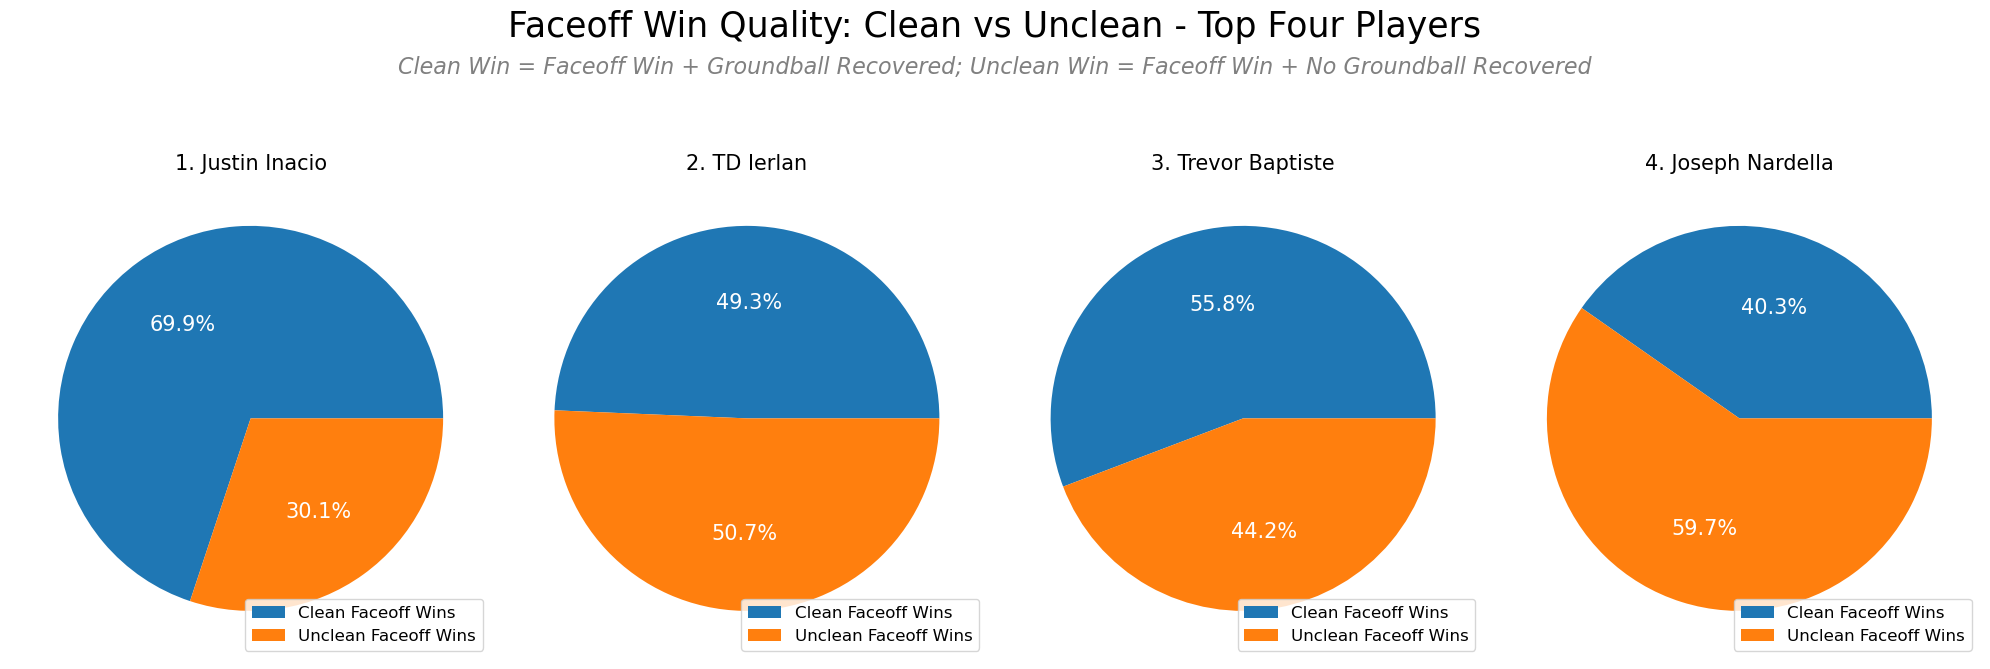

In [145]:
fig_FO, ax_FO = plt.subplots(1,4, figsize=(20,8))

fig_FO.suptitle("Faceoff Win Quality: Clean vs Unclean - Top Four Players",fontsize=25)
fig_FO.text(0.5, 0.9, "Clean Win = Faceoff Win + Groundball Recovered; Unclean Win = Faceoff Win + No Groundball Recovered", 
           ha='center', fontsize=16, style='italic', color='gray')

ax_FO[0].pie(justin_inacio_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_FO[0].set_title("1. Justin Inacio", fontsize=15)
ax_FO[0].legend(labels=fo_labels, loc="lower right", fontsize=12)

ax_FO[1].pie(td_ierlan_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_FO[1].set_title("2. TD Ierlan", fontsize=15)
ax_FO[1].legend(labels=fo_labels, loc="lower right", fontsize=12)

ax_FO[2].pie(trevor_baptiste_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_FO[2].set_title("3. Trevor Baptiste", fontsize=15)
ax_FO[2].legend(labels=fo_labels, loc='lower right', fontsize=12)

ax_FO[3].pie(joseph_nardella_values, autopct ='%1.1f%%', textprops={"fontsize":15, "color":"white"})
ax_FO[3].set_title("4. Joseph Nardella", fontsize=15)
ax_FO[3].legend(labels=fo_labels, loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

**Analysis**<br>
In the top four players (as determined earlier), the player with the highest percentage of clean faceoff wins is Justin Inacio, who placed first in the rankings. This supports his reputation as a skilled faceoff player. The other top faceoff players have approximately balanced amounts of clean and unclean faceoff wins. The variation in proportion could suggest that the midfielder teammates play a larger role in faceoff wins and starting plays on those teams. It could indicate stronger teamwork and coordination within the team.

## Goalie Analysis
We continue by analyzing the final defensive position: goalie.

### General Distribution of Statistics

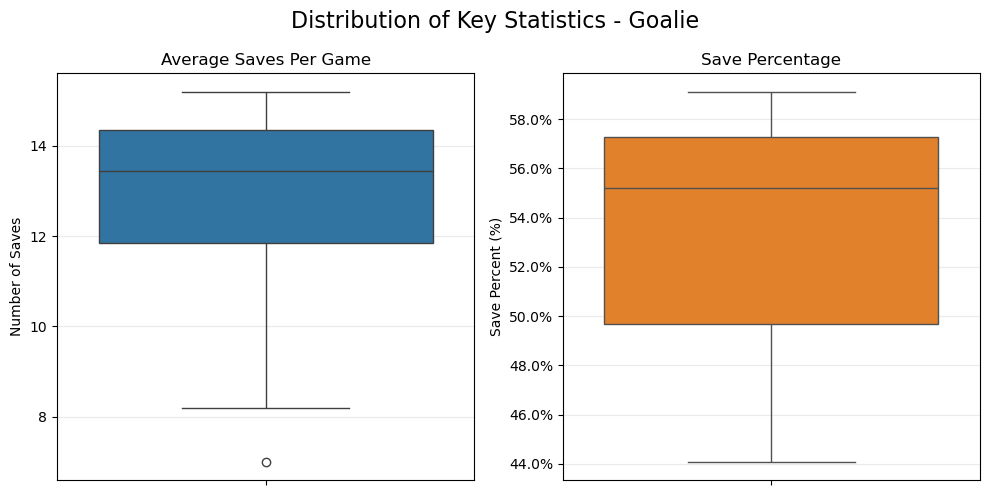

In [167]:
#goalie plots

pos_6 = positional_analysis[positional_analysis["Position"]=="G"]
stat_6 = position_stats["G"]
titles_6 = ["Average Saves Per Game", "Save Percentage"]
colors_1 = sns.color_palette()

fig_6, axes_6 = plt.subplots(1,2,figsize = (10,5))
fig_6.suptitle(f"Distribution of Key Statistics - Goalie", fontsize = 16)

for AX, STAT, TITLE, color in zip(axes_6, stat_6, titles_6, colors_1):
    sns.boxplot(data =pos_6, y=STAT, ax = AX, color = color)
    AX.set_title(TITLE)
    AX.set_ylabel("")
    AX.grid(True, axis = 'y',alpha = 0.25)

axes_6[0].set_ylabel("Number of Saves")
axes_6[1].set_ylabel("Save Percent (%)")
axes_6[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

In [168]:
pos_6[["Avg Saves/Game", "Save %"]].describe()

,Avg Saves/Game,Save %
count,10.000000,10.000000
mean,12.412976,0.533387
std,2.788514,0.051906
min,7.000000,0.440860
25%,11.850000,0.496875
50%,13.435714,0.552057
75%,14.356250,0.572665
max,15.200000,0.591093


**Analysis**<br>
The average number of saves per game is skewed upwards, which indicates the high number of shots a goalie faces each game. 50% of the goalies have a save percentage between 49.7% and 57.3%, which demonstrates the high level of skill required to compete with the top goalies in the PLL.

### Best Players By Statistic
A similar method to above is used to determine the best players.

In [169]:
#create positional database
best_goalies = positional_analysis[positional_analysis["Position"]=="G"]

#find rank of each player per statistic
top_goalies = best_goalies.copy()
top_goalies["savepc_rank"]=top_goalies["Save %"].rank(ascending=False)
top_goalies["saveavg_rank"]=top_goalies["Avg Saves/Game"].rank(ascending=False)

#find avg rank -lower is better - evenly rated criteria
top_goalies["avg_rank"]=top_goalies[["savepc_rank", "saveavg_rank"]].mean(axis=1)
top_G = top_goalies.sort_values("avg_rank")
top_G[["First Name", "Last Name", "Team", "Save %", "Avg Saves/Game"]].head(10)


,First Name,Last Name,Team,Save %,Avg Saves/Game
171,Brett,Dobson,Archers,0.591093,14.600000
137,Liam,Entenmann,Atlas,0.571429,15.200000
145,Blaze,Riorden,Chaos,0.573077,14.900000
174,Logan,McNaney,Outlaws,0.582888,13.625000
188,Emmet,Carroll,Whipsnakes,0.562130,13.571429
172,Colin,Kirst,Cannons,0.500000,13.300000
148,Matt,DeLuca,Waterdogs,0.541985,11.833333
186,Chayse,Ierlan,Redwoods,0.495833,11.900000
181,Brendan,Krebs,Whipsnakes,0.474576,7.000000
144,Dillon,Ward,Waterdogs,0.440860,8.200000


**Analysis**<br>
Logan McNaney was the Goalie of the Year in the Lexus End of Season Awards. He placed fourth in the statistical rankings, which somewhat aligns with industry results. For further analysis, I placed the players' teams into a table. Brett Dobson, Logan McNaney and Liam Entenmann were highly regarded as the top goalies of the season, and the Archers, Outlaws, and Atlas (their teams, respectively) were in the top four ranked teams of the Regular Season.

### Investigating Top Players
To look into what statistics differentiate the top players, I investigated the clean save percentages for all goalies.

Text(0.3894736842105263, -0.1, 'Carroll: 0.39')

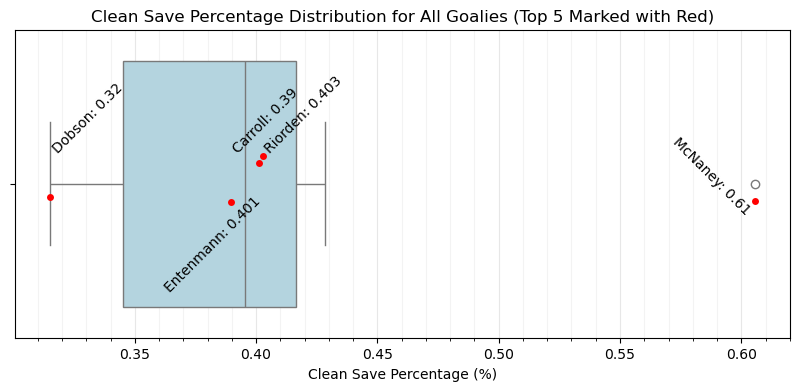

In [171]:
#create brett dobson profile
best_goalies_copy = top_G.copy()
top5goalies = best_goalies_copy.head(5)

brett_dobson_G = top5goalies.iloc[0]
logan_mcnaney_G = top5goalies.iloc[3]
blaze_riorden_G = top5goalies.iloc[2]
liam_entenmann_G = top5goalies.iloc[1]
emmet_carroll_G = top5goalies.iloc[4]


fig_G, ax_G=plt.subplots(figsize=(10,4))

sns.boxplot(x=pos_6["Clean Save %"],ax=ax_G , orient='h', color='lightblue')
sns.stripplot(x=top5goalies["Clean Save %"],ax=ax_G, color="red", zorder=3)
ax_G.set_title("Clean Save Percentage Distribution for All Goalies (Top 5 Marked with Red)")
ax_G.set_xlabel("Clean Save Percentage (%)")
ax_G.minorticks_on()
ax_G.grid(True, axis='x', which='major', alpha=0.3)
ax_G.grid(True, axis='x', which='minor', alpha=0.15)

ax_G.annotate(f"{brett_dobson_G["Last Name"]}: {brett_dobson_G["Clean Save %"]:.2}", xy=(brett_dobson_G["Clean Save %"],-.1),rotation=45)
ax_G.annotate(f"{logan_mcnaney_G["Last Name"]}: {logan_mcnaney_G["Clean Save %"]:.2}", xy=(logan_mcnaney_G["Clean Save %"]-0.035,.1),rotation=-45)
ax_G.annotate(f"{blaze_riorden_G["Last Name"]}: {blaze_riorden_G["Clean Save %"]:.3}", xy=(blaze_riorden_G["Clean Save %"],-.1),rotation=45)
ax_G.annotate(f"{liam_entenmann_G["Last Name"]}: {liam_entenmann_G["Clean Save %"]:.3}", xy=(liam_entenmann_G["Clean Save %"]-.04,.35),rotation=45)
ax_G.annotate(f"{emmet_carroll_G["Last Name"]}: {emmet_carroll_G["Clean Save %"]:.2}", xy=(emmet_carroll_G["Clean Save %"],-.1),rotation=45)


I plotted the overall distribution of clean save percentages for all goalies. I labeled the "Clean Save Percentage" for the top five goalies according to the above ranking. My goal was to determine if there was a correlation between a higher rank and higher clean save rates. From this boxplot, it is clear that the top goalies (with better overall save percentages) do not necessarily have better clean save percentages. 

I considered continuing my investigation with a hypothesis test to determine the correlation between overall save percentage and clean save percentage. However, I decided against it because there are only 10 goalies, which is a very limited sample and the tests would be extra prone to error.

IDEA - take each team and average the ranking of each of the players on the team per position to determine top teams?